In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [5]:
titanic = sns.load_dataset("titanic")
titanic_df = titanic.copy()

In [6]:
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
# Duplicated values
titanic_df.duplicated().sum()

np.int64(107)

In [9]:
titanic_df = titanic_df.drop_duplicates()

In [10]:
# Split input & output and test & train
X = titanic_df[["pclass", "sex", "age", "fare", "embarked"]]
y = titanic_df["survived"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, shuffle=True, stratify=y)

In [12]:
# Filling missing values
numeric_imputer = SimpleImputer(strategy="median").set_output(transform="pandas")
X_train["age"] = numeric_imputer.fit_transform(X_train[["age"]])
X_test["age"] = numeric_imputer.transform(X_test[["age"]])

In [13]:
category_imputer = SimpleImputer(strategy="most_frequent").set_output(transform="pandas")
X_train["embarked"] = category_imputer.fit_transform(X_train[["embarked"]])
X_test["embarked"] = category_imputer.transform(X_test[["embarked"]])

In [14]:
# Feature engineering
# Encoding
# Label Encoding
le = LabelEncoder()
X_train["sex"] = le.fit_transform(X_train["sex"])
X_test["sex"] = le.transform(X_test["sex"])

In [15]:
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore").set_output(transform="pandas")
X_train_encoded = ohe.fit_transform(X_train[["embarked"]])
X_train = pd.concat([X_train.drop("embarked", axis=1), X_train_encoded], axis=1)
X_test_encoded = ohe.transform(X_test[["embarked"]])
X_test = pd.concat([X_test.drop("embarked", axis=1), X_test_encoded], axis=1)

In [16]:
# Model training - no pruning
model_dtc = DecisionTreeClassifier()
model_dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
# Model evaluation
y_test_pred = model_dtc.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Decision Tree Classifier:
Accuracy: 0.7288135593220338
Precision: 0.6571428571428571
Recall: 0.711340206185567
F1: 0.6831683168316832
[[103  36]
 [ 28  69]]


In [18]:
# Model evaluation - training
y_train_pred = model_dtc.predict(X_train)

accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)
cm = confusion_matrix(y_train, y_train_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

# Model is overfit

Decision Tree Classifier:
Accuracy: 0.9817518248175182
Precision: 1.0
Recall: 0.9557522123893806
F1: 0.9773755656108597
[[322   0]
 [ 10 216]]


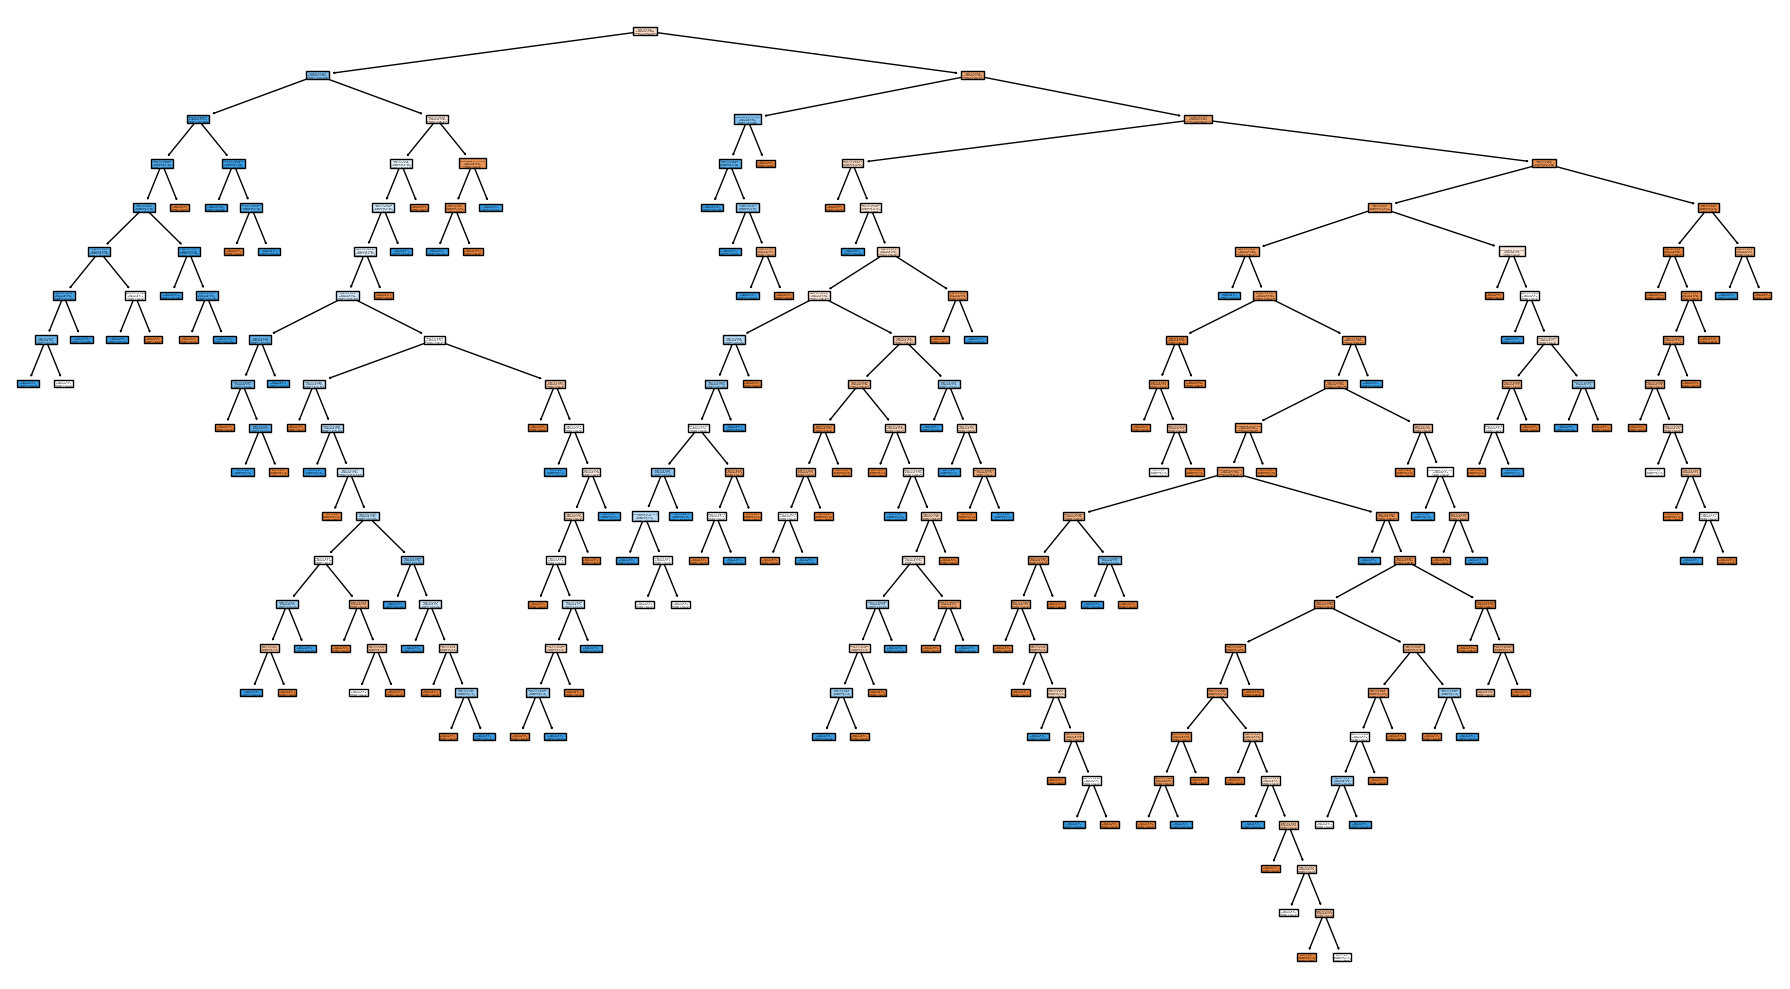

In [19]:
plt.figure(figsize=(18, 10))
plot_tree(
    model_dtc,
    feature_names=X_train.columns,
    class_names=["Died", "Survived"],
    filled=True,
)
plt.tight_layout()
# plt.show()

In [20]:
# Model training - with pre pruning
max_depths = np.arange(1, 20)

for max_depth in max_depths:
    model_dtc = DecisionTreeClassifier(max_depth=max_depth)
    model_dtc.fit(X_train, y_train)
    y_test_pred = model_dtc.predict(X_test)

    accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    cm = confusion_matrix(y_test, y_test_pred)
    
    print("Decision Tree Classifier:", max_depth, "Accuracy:", accuracy)

# Best Depth: 3

Decision Tree Classifier: 1 Accuracy: 0.788135593220339
Decision Tree Classifier: 2 Accuracy: 0.7542372881355932
Decision Tree Classifier: 3 Accuracy: 0.7796610169491526
Decision Tree Classifier: 4 Accuracy: 0.7796610169491526
Decision Tree Classifier: 5 Accuracy: 0.8008474576271186
Decision Tree Classifier: 6 Accuracy: 0.7711864406779662
Decision Tree Classifier: 7 Accuracy: 0.7542372881355932
Decision Tree Classifier: 8 Accuracy: 0.7288135593220338
Decision Tree Classifier: 9 Accuracy: 0.7372881355932204
Decision Tree Classifier: 10 Accuracy: 0.7627118644067796
Decision Tree Classifier: 11 Accuracy: 0.75
Decision Tree Classifier: 12 Accuracy: 0.7372881355932204
Decision Tree Classifier: 13 Accuracy: 0.7330508474576272
Decision Tree Classifier: 14 Accuracy: 0.7457627118644068
Decision Tree Classifier: 15 Accuracy: 0.7372881355932204
Decision Tree Classifier: 16 Accuracy: 0.7415254237288136
Decision Tree Classifier: 17 Accuracy: 0.7288135593220338
Decision Tree Classifier: 18 Accuracy:

In [21]:
np.arange(0, 50, 10)

array([ 0, 10, 20, 30, 40])

In [22]:
min_samples_splits = np.arange(5,  50, 5)

for min_samples_split in min_samples_splits:
    model_dtc = DecisionTreeClassifier(max_depth=3, min_samples_split=min_samples_split)
    model_dtc.fit(X_train, y_train)
    y_test_pred = model_dtc.predict(X_test)

    accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    cm = confusion_matrix(y_test, y_test_pred)
    
    print("Decision Tree Classifier:", min_samples_split, "Accuracy:", accuracy)

# Best split: 10

Decision Tree Classifier: 5 Accuracy: 0.7796610169491526
Decision Tree Classifier: 10 Accuracy: 0.7796610169491526
Decision Tree Classifier: 15 Accuracy: 0.7796610169491526
Decision Tree Classifier: 20 Accuracy: 0.7796610169491526
Decision Tree Classifier: 25 Accuracy: 0.7796610169491526
Decision Tree Classifier: 30 Accuracy: 0.7796610169491526
Decision Tree Classifier: 35 Accuracy: 0.7796610169491526
Decision Tree Classifier: 40 Accuracy: 0.7796610169491526
Decision Tree Classifier: 45 Accuracy: 0.7796610169491526


In [23]:
# Model training - with post pruning
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.        , 0.        , 0.00030414, 0.00036496, 0.0004562 ,
       0.00048662, 0.00057448, 0.00060827, 0.00060827, 0.00072993,
       0.00077472, 0.00078656, 0.00079075, 0.0008342 , 0.00104275,
       0.00111517, 0.00121655, 0.00135172, 0.00137875, 0.00145985,
       0.00156413, 0.00156413, 0.00170245, 0.00176189, 0.00179674,
       0.00180306, 0.00191391, 0.00202758, 0.00204434, 0.00218978,
       0.00218978, 0.00225392, 0.00232664, 0.00261477, 0.00270343,
       0.00273723, 0.00281543, 0.00291971, 0.0030124 , 0.00313293,
       0.00319343, 0.00319343, 0.00335932, 0.00339662, 0.00437029,
       0.00468406, 0.00772074, 0.00921341, 0.01901519, 0.02568183,
       0.04284855, 0.11936216])

In [25]:
models = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    models.append((model, alpha))

In [26]:
best_ccp = 0
best_accuracy = 0
for model, alpha in models:
    curr = model.score(X_test, y_test)
    if curr > best_accuracy:
        best_accuracy = curr
        best_ccp = alpha

print(best_ccp)
print(best_accuracy)

0.042848552049775224
0.788135593220339


Decision Tree Classifier:
Accuracy: 0.788135593220339
Precision: 0.7422680412371134
Recall: 0.7422680412371134
F1: 0.7422680412371134
[[114  25]
 [ 25  72]]


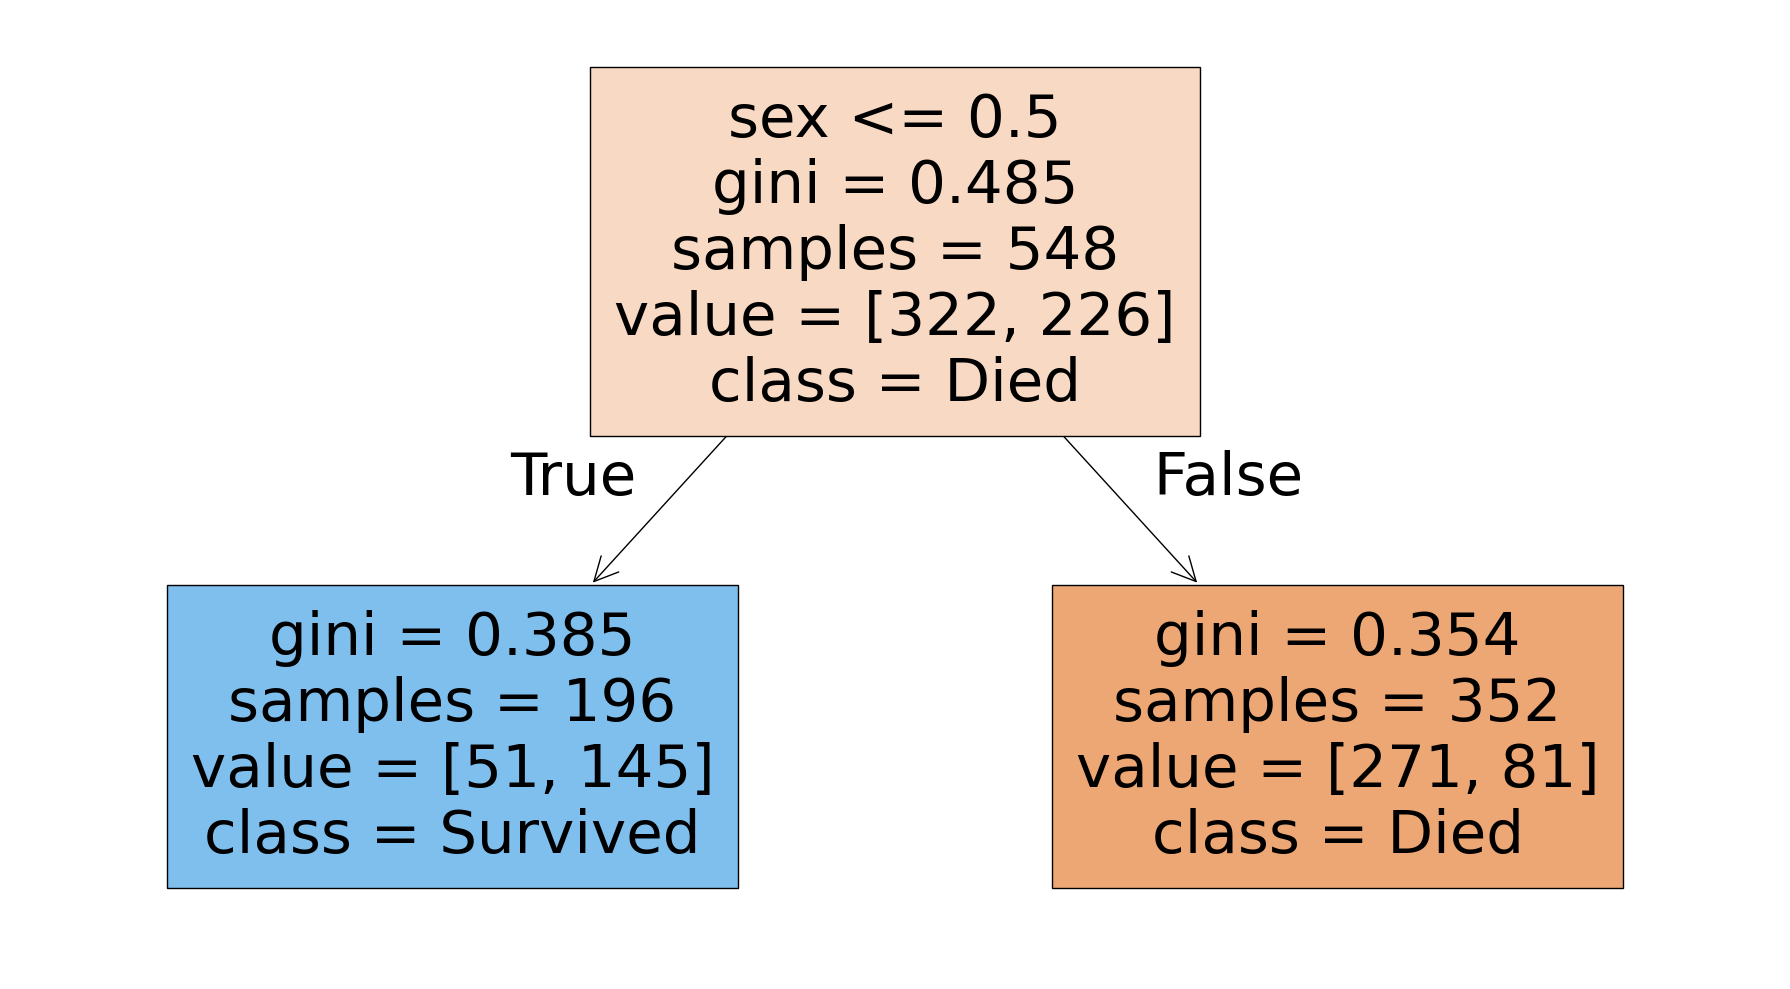

In [27]:
model_dtc = DecisionTreeClassifier(ccp_alpha=best_ccp)
model_dtc.fit(X_train, y_train)

y_test_pred = model_dtc.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

plt.figure(figsize=(18, 10))
plot_tree(
    model_dtc,
    feature_names=X_train.columns,
    class_names=["Died", "Survived"],
    filled=True,
)
plt.tight_layout()

In [28]:
# Model training - pre pruning with cross validation
model_dtc_cv = GridSearchCV(
    DecisionTreeClassifier(),
    {"max_depth": np.arange(1, 20),
    "min_samples_split": np.arange(5, 50, 5),
    #"ccp_alpha": ccp_alphas
    },
    cv=5,
    scoring="accuracy"
)

model_dtc_cv.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': array([ 1, 2... 18, 19]), 'min_samples_split': array([ 5, 10..., 35, 40, 45])}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [29]:
y_test_pred = model_dtc_cv.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Decision Tree Classifier:
Accuracy: 0.7796610169491526
Precision: 0.7227722772277227
Recall: 0.7525773195876289
F1: 0.7373737373737373
[[111  28]
 [ 24  73]]


In [30]:
# Model training - Random forest classifier
rfc_model = RandomForestClassifier(
    n_estimators=201,
    oob_score=True,
)

rfc_model.fit(X_train, y_train)


,n_estimators,201
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [ ]:
# Model evaluation
y_test_pred = rfc_model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Decision Tree Classifier:
Accuracy: 0.7669491525423728
Precision: 0.7019230769230769
Recall: 0.7525773195876289
F1: 0.7263681592039801
[[108  31]
 [ 24  73]]


In [ ]:
y_train_pred = rfc_model.predict(X_train)

accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)
cm = confusion_matrix(y_train, y_train_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

In [34]:
# Pruning on Random Forest
rfc_cv_model = GridSearchCV(
    RandomForestClassifier(
        n_estimators=201,
        oob_score=True,
    ),
    {
        "max_depth": np.arange(1, 20),
        "min_samples_split": np.arange(5, 50, 5),
    },
    cv=5,
)

rfc_cv_model.fit(X_train, y_train)

,estimator,RandomForestC...ob_score=True)
,param_grid,"{'max_depth': array([ 1, 2... 18, 19]), 'min_samples_split': array([ 5, 10..., 35, 40, 45])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,201


In [36]:
y_test_pred = rfc_cv_model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Decision Tree Classifier:
Accuracy: 0.7754237288135594
Precision: 0.7340425531914894
Recall: 0.711340206185567
F1: 0.7225130890052356
[[114  25]
 [ 28  69]]
